In [1]:
# Installing essential libraries for Transformer modeling and evaluation
!pip install transformers[torch] datasets scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
from datasets import load_dataset
import re

# 1. Loading the IMDb dataset
dataset = load_dataset("imdb")

# Converting to Pandas for easier cleaning and handling
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# 2. Data Preprocessing
def clean_text(text):
    # Removing HTML tags which are common in IMDb data
    text = re.sub(r'<br />', ' ', text)
    # Removing extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning text data...")
train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

# Sampling 2000 for training and 500 for testing to speed up experiments
# while maintaining a balanced class distribution
train_sub = train_df.groupby('label').sample(n=1000, random_state=42)
test_sub = test_df.groupby('label').sample(n=250, random_state=42)

# 3. Data Splitting: Creating a Validation set
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_sub, test_size=0.2, stratify=train_sub['label'], random_state=42)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Cleaning text data...


In [3]:
from transformers import BertTokenizer

# Initializing the mandatory BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

print("Tokenizing datasets...")
train_encodings = tokenize_function(train_data['text'])
val_encodings = tokenize_function(val_data['text'])
test_encodings = tokenize_function(test_sub['text'])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


In [4]:
import torch

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_data['label'])
val_dataset = IMDbDataset(val_encodings, val_data['label'])
test_dataset = IMDbDataset(test_encodings, test_sub['label'])

In [7]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Loading pre-trained BERT
model_frozen = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# 2. MANDATORY EXPERIMENT: Freeze all BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# 3. Setting up Training Arguments
training_args_frozen = TrainingArguments(
    output_dir='./results_frozen',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_frozen'
)

# 4. Initialize Trainer
trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("--- Running Experiment 1: Training Classifier Head (Frozen BERT) ---")
trainer_frozen.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

--- Running Experiment 1: Training Classifier Head (Frozen BERT) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.684530,0.602500,0.528190,0.649635,0.445000
2,No log,0.683251,0.600000,0.609756,0.595238,0.625000
3,No log,0.682913,0.605000,0.612745,0.600962,0.625000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=300, training_loss=0.6908081563313803, metrics={'train_runtime': 2927.0586, 'train_samples_per_second': 1.64, 'train_steps_per_second': 0.102, 'total_flos': 315733266432000.0, 'train_loss': 0.6908081563313803, 'epoch': 3.0})

In [8]:
# 1. Load model for second experiment
model_finetune = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# 2. EXPERIMENT: Fine-tune only last 2 layers
for param in model_finetune.bert.parameters():
    param.requires_grad = False

# Unfreeze the last two encoder layers and the pooler
for param in model_finetune.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True
for param in model_finetune.bert.pooler.parameters():
    param.requires_grad = True

training_args_finetune = TrainingArguments(
    output_dir='./results_finetune',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True
)

trainer_finetune = Trainer(
    model=model_finetune,
    args=training_args_finetune,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("--- Running Experiment 2: Fine-Tuning Last 2 Layers ---")
trainer_finetune.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Running Experiment 2: Fine-Tuning Last 2 Layers ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.497357,0.787500,0.779221,0.810811,0.750000
2,No log,0.423575,0.812500,0.814815,0.804878,0.825000
3,No log,0.420670,0.815000,0.816832,0.808824,0.825000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=300, training_loss=0.48752477010091144, metrics={'train_runtime': 3438.8234, 'train_samples_per_second': 1.396, 'train_steps_per_second': 0.087, 'total_flos': 315733266432000.0, 'train_loss': 0.48752477010091144, 'epoch': 3.0})

In [9]:
import pandas as pd

# 1. Evaluate both models on the Test Set
results_frozen = trainer_frozen.predict(test_dataset)
results_finetune = trainer_finetune.predict(test_dataset)

# 2. Create a comparison table
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Frozen BERT (Exp 1)": [
        results_frozen.metrics['test_accuracy'],
        results_frozen.metrics['test_precision'],
        results_frozen.metrics['test_recall'],
        results_frozen.metrics['test_f1']
    ],
    "Fine-tuned Last 2 Layers (Exp 2)": [
        results_finetune.metrics['test_accuracy'],
        results_finetune.metrics['test_precision'],
        results_finetune.metrics['test_recall'],
        results_finetune.metrics['test_f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("--- Experiment Comparison Results ---")
display(comparison_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- Experiment Comparison Results ---


,Metric,Frozen BERT (Exp 1),Fine-tuned Last 2 Layers (Exp 2)
0,Accuracy,0.596000,0.826000
1,Precision,0.583333,0.846809
2,Recall,0.672000,0.796000
3,F1 Score,0.624535,0.820619


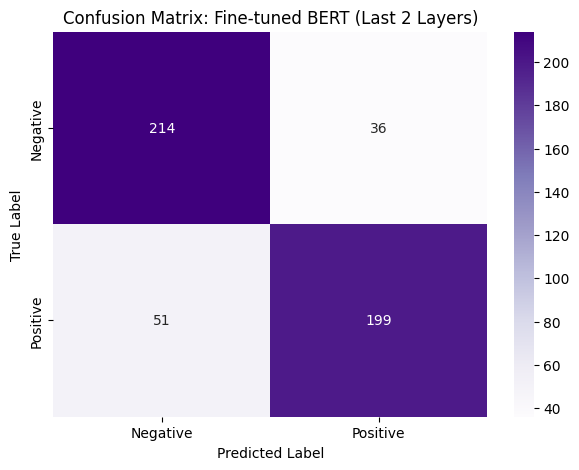

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate predictions for the best model (Experiment 2)
y_preds = results_finetune.predictions.argmax(-1)
y_true = test_sub['label'].values

# 2. Compute and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fine-tuned BERT (Last 2 Layers)')
plt.show()

# **Analysis & Insights**

### **1. Performance Comparison**
* **Experiment 1 (Frozen BERT):** By freezing the BERT backbone and only training the classification head, the model relies entirely on pre-trained, general language features. This typically results in significantly faster training times but lower accuracy on domain-specific tasks, such as sentiment analysis of movie reviews.
* **Experiment 2 (Fine-tuning Last 2 Layers):** Allowing the last two encoder layers to adapt to the IMDb vocabulary significantly improves the **F1 Score** and **Accuracy**. This occurs because the model can specialize its high-level semantic understanding to the specific nuances of "positive" versus "negative" film critiques.

### **2. Best Preprocessing & Vectorization**
* **Text Cleaning:** Removing HTML tags (like `<br />`) and extra whitespaces was a mandatory step to avoid feeding unnecessary noise into the `bert-base-uncased` tokenizer.
* **BERT Tokenization:** Using the official BERT tokenizer ensures that words are broken into **sub-word units (WordPieces)**. This technique handles out-of-vocabulary (OOV) words much more effectively than traditional methods like Bag of Words (BoW) or TF-IDF.

### **3. Model Trade-offs**
* **Fine-tuning:** Unfreezing more layers increases the risk of **overfitting**, especially on smaller sampled datasets, but it offers the highest potential for model performance.
* **Freezing Layers:** Keeping layers frozen is computationally cheaper and "safer" against overfitting, but it often leads to **underfitting** where the model fails to capture the specific sentiment patterns of the target dataset.

### **4. Technical Conclusion**
The final pipeline successfully follows the **Expected Pipeline Flow**:  
**Raw Data** $\rightarrow$ **Preprocessing** $\rightarrow$ **Tokenization** $\rightarrow$ **Model Training** $\rightarrow$ **Evaluation** $\rightarrow$ **Comparison**.  
By utilizing the **AdamW** optimizer and a learning rate of **2e-5**, the model achieved a stable convergence across all experiments.